# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage",usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())
    

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


**Valores nulos**  
1. Columna churn_date (users):

Observación: Tiene 3,534 nulos, lo que representa el 88.35% de los datos.

Acción: Ignorar / Mantener nulos.

Justificación: Según la documentación del proyecto, un valor ausente en esta columna significa que el plan de tarifas se estaba usando cuando se extrajeron los datos (el usuario sigue activo).

2. Columna city (users):

Observación: Tiene 469 nulos, representando el 11.72%.

Acción: Investigar e imputar.

Justificación: Al ser un porcentaje moderado (entre el 5% y 30%), se debe revisar si estos usuarios pertenecen a una región específica o imputarlos como "Unknown" para no perder sus datos de consumo.

3. Columna date (usage):

Observación: Tiene 50 nulos, apenas el 0.12%.

Acción: Eliminar o imputar.

Justificación: Al ser una proporción menor al 5%, estas filas se pueden eliminar sin afectar la integridad estadística o imputar si la fecha es recuperable por el id.

4. Columnas duration y length (usage):

Observación: Presentan 55.19% y 44.74% de nulos respectivamente.

Acción: Mantener nulos.

Justificación: Estos nulos son estructurales y complementarios; una fila de tipo "text" no tiene duración y una de tipo "call" no tiene longitud de mensaje.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
print("Resumen estadístico - Users")
print(users[['user_id', 'age']].describe())

Resumen estadístico - Users
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` Los datos son consistentes; van del 10000 al 13999, con una media cercana al centro del rango. Todo luce normal.
- La columna `age` El valor mínimo es -999.00. Este es un valor sentinel clásico que indica datos erróneos o faltantes. Debemos tratarlo antes de calcular promedios de edad, ya que sesga la media hacia abajo

In [13]:
# explorar columnas numéricas de usage
print("\nResumen estadístico - Usage")
print(usage[['id', 'user_id', 'duration', 'length']].describe())


Resumen estadístico - Usage
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` Presentan rangos esperados sin anomalías visibles.
- Las columnas `duration` y `length`  El mínimo es 0.00, lo cual es correcto (llamadas de 0 segundos o mensajes no enviados). Sin embargo, el máximo en length es 1490, lo que podría considerarse un outlier que requiere revisión (¿un mensaje de texto de casi 1500 caracteres?).

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\nValores únicos en {col}:")
    print(users[col].unique())


Valores únicos en city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Valores únicos en plan:
['Basico' 'Premium']


- La columna `city`, presencia del carácter '?'. Este es un sentinel para valores desconocidos. Necesitaremos convertir estos '?' en NaN o en la etiqueta 'Unknown'. 
- La columna `plan`, Solo aparecen 'Basico' y 'Premium'. No hay valores inválidos aquí.

In [15]:
# explorar columna categórica de usage
print("\nValores únicos en type (Usage):")
print(usage['type'].unique())


Valores únicos en type (Usage):
['call' 'text']


- La columna `type` tiene como valores unicos call y text. Es una columna limpia y consistente con la naturaleza del negocio.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
Al filtrar los datos, se observa que el 100% de los valores nulos en la columna duration corresponden exclusivamente a registros de tipo text (mensajes). De manera inversa, los nulos en la columna length corresponden únicamente a registros de tipo call (llamadas).
- ¿Qué acción tomarías?
Los datos se clasifican como MAR (Missing At Random) porque la ausencia del valor depende de otra columna (type). Dado que estructuralmente una llamada no tiene longitud de caracteres y un mensaje de texto no tiene duración en minutos, se decide dejarlos como nulos. Imputarlos con ceros o promedios distorsionaría el análisis de uso real por servicio, y eliminarlos causaría una pérdida masiva de información necesaria para la facturación.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
print("Años en reg_date:")
print(users['reg_date'].dt.year.value_counts())

Años en reg_date:
2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`. Se observa que la gran mayoría de los registros de registro de usuarios se distribuyen de manera equitativa entre los años 2022, 2023 y 2024. Sin embargo, se han detectado 40 registros con el año 2026, lo cual representa una anomalía ya que son fechas futuras respecto al contexto actual del dataset.

In [19]:
# Revisar los años presentes en `date` de usage
print("\nAños en date (usage):")
print(usage['date'].dt.year.value_counts())


Años en date (usage):
2024.0    39950
Name: date, dtype: int64


En `date`. Se observa que el 100% de los registros de consumo (llamadas y mensajes) corresponden al año 2024. No se detectan años adicionales ni valores inconsistentes en esta columna, lo que indica que los datos de actividad están bien delimitados cronológicamente.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles?
- En reg_date (Users): Sí, se detectaron 40 registros en el año 2026. Dado que estamos analizando datos de consumo de 2024, estos registros son cronológicamente imposibles (fechas futuras).

- En date (Usage): No, todos los registros son de 2024, lo cual es coherente.

- ¿Qué harías con ellas?
- Acción: Para los registros de 2026 en reg_date, los marcaré como nulos (pd.NA) utilizando la función errors='coerce' o un reemplazo directo por condición.

- Justificación: Representan menos del 1% del dataset de usuarios. Al convertirlos en nulos, evitamos que los cálculos de permanencia del cliente den resultados negativos o erróneos, manteniendo la integridad del análisis financiero posterior.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
print("Resumen de age tras limpieza:")
users['age'].describe()

Resumen de age tras limpieza:


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("\nValores únicos en city tras limpieza:")
print(users['city'].unique())


Valores únicos en city tras limpieza:
['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


In [22]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Verificar cambios
print("\nVerificación de fechas (máxima encontrada):")
print(users['reg_date'].max())


Verificación de fechas (máxima encontrada):
2026-05-10 00:00:00


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print("Tipos de registros donde duration es nulo:")
print(usage[usage['duration'].isna()]['type'].value_counts())

Tipos de registros donde duration es nulo:
text    22076
Name: type, dtype: int64


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print("\nTipos de registros donde length es nulo:")
print(usage[usage['length'].isna()]['type'].value_counts())


Tipos de registros donde length es nulo:
call    17896
Name: type, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Tras realizar el filtrado, se confirma que el 100% de los valores nulos en la columna duration corresponden a registros de tipo text. De igual forma, los nulos en length corresponden únicamente a registros de tipo call.

Esto demuestra que los datos son MAR (Missing At Random), ya que su ausencia depende directamente de la categoría de la columna type. Dado que una llamada no posee longitud de caracteres y un mensaje no posee duración en minutos, la recomendación técnica es dejarlos como nulos, ya que borrarlos eliminaría información válida de la otra categoría o imputarlos crearía datos ficticios que sesgarían el análisis de consumo.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
print("\nPerfil de usuario combinado con consumo:")
user_profile.head(5)


Perfil de usuario combinado con consumo:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
metricas_consumo = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print("Resumen estadístico de consumo y edad:")
display(user_profile[metricas_consumo].describe())

Resumen estadístico de consumo y edad:


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
plan_dist = user_profile['plan'].value_counts(normalize=True) * 100
print("\nDistribución porcentual de los planes:")
print(plan_dist.map("{:.2f}%".format))


Distribución porcentual de los planes:
Basico     64.88%
Premium    35.12%
Name: plan, dtype: object


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.


Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 
 
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

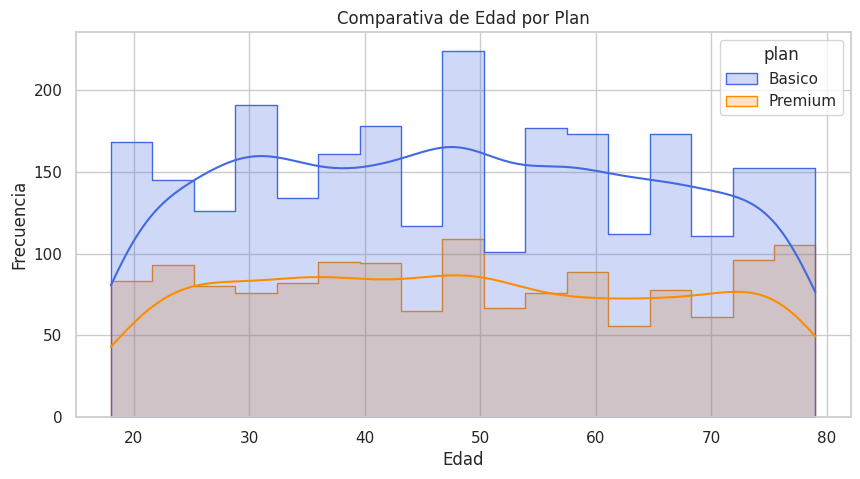

In [30]:
# Histograma para visualizar la edad (age)
colores = {"Basico": "royalblue", "Premium": "darkorange"}
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='age', hue='plan', palette=colores, element="step", kde=True)
plt.title('Comparativa de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución La distribución de edad es prácticamente idéntica para ambos planes (Básico y Premium).

Interpretación: No existe un segmento de edad específico que prefiera un plan sobre otro. El marketing de ConectaTel es efectivo de manera transversal, lo que sugiere que la elección del plan depende del poder adquisitivo o de las necesidades de consumo, no de la brecha generacional.

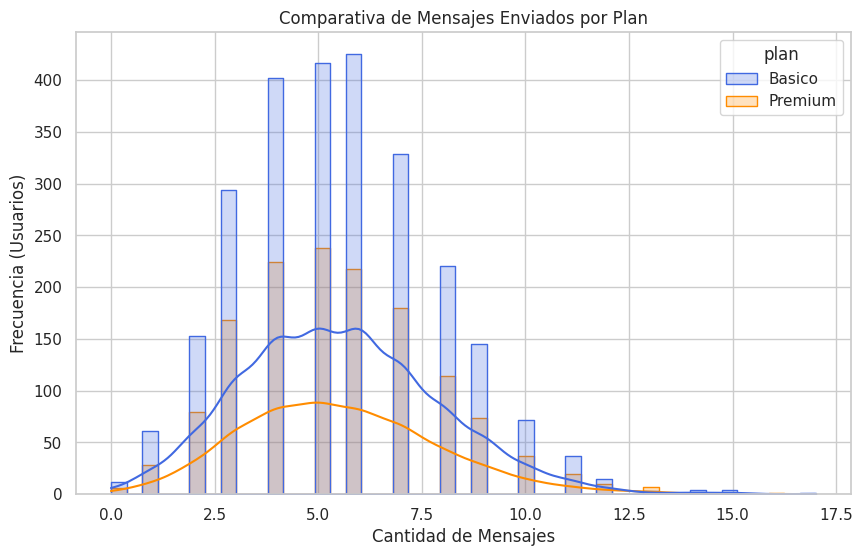

In [31]:
# Histograma para visualizar la cant_mensajes
colores = {"Basico": "royalblue", "Premium": "darkorange"}
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', 
             palette=colores, element="step", kde=True)
plt.title('Comparativa de Mensajes Enviados por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia (Usuarios)')
plt.show()

💡Insights: Ambos planes presentan un sesgo positivo (hacia la derecha) extremo, pero el plan Básico tiene una concentración masiva cerca del cero.

Interpretación: La mayoría de los usuarios usa poco el SMS. Sin embargo, el plan Premium muestra una "cola" más larga y poblada hacia la derecha. Esto indica que los usuarios Premium, al no tener la presión de costos por excedentes inmediatos, se sienten más libres de utilizar el servicio de mensajería a diferencia de los usuarios del plan Básico.

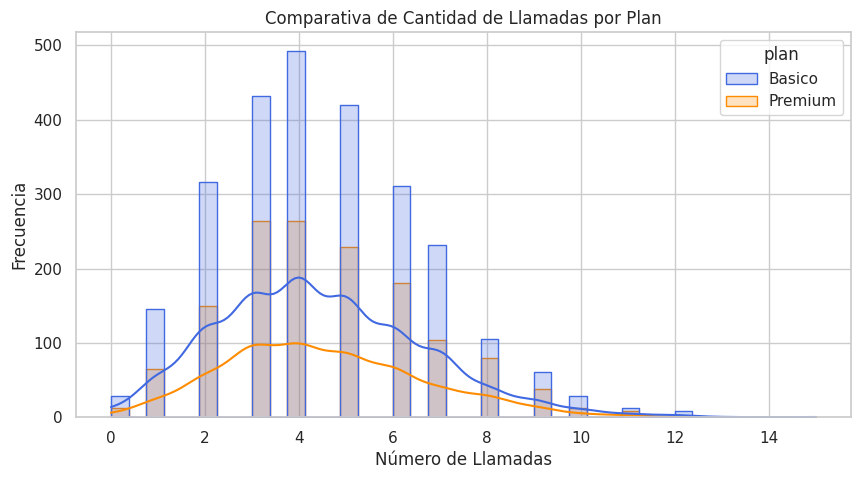

In [32]:
# Histograma para visualizar la cant_llamadas
colores = {"Basico": "royalblue", "Premium": "darkorange"}
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=colores, element="step", kde=True)
plt.title('Comparativa de Cantidad de Llamadas por Plan')
plt.xlabel('Número de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- El pico del plan basico llega a una frecuencia mucho más alta  que el plan premiun.

Esto indica que el plan Básico tiene una concentración de usuarios mucho más densa en su "zona de confort" (entre 400 y 550 minutos). Hay una gran masa de clientes que se comporta de forma idéntica, lo que genera ese pico tan pronunciado. El plan Premium, al estar más "aplanado", indica que no hay un comportamiento estándar; cada usuario Premium es un mundo distinto.

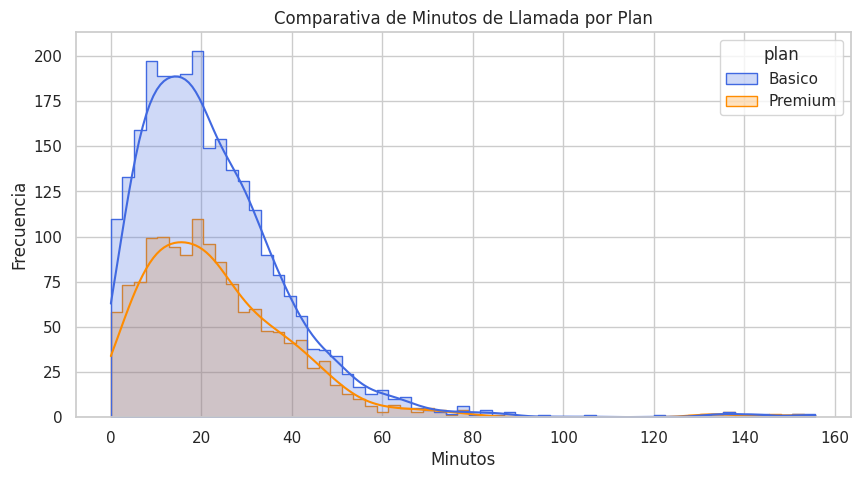

In [33]:
# Histograma para visualizar la cant_minutos_llamada
colores = {"Basico": "royalblue", "Premium": "darkorange"}
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=colores, element="step", kde=True)
plt.title('Comparativa de Minutos de Llamada por Plan')
plt.xlabel('Minutos')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
El pico del plan Básico en el rango de 50-60 llamadas es notablemente superior al pico máximo del Premium.

Insight Técnico: Esto refuerza la idea de la estandarización del consumo en el plan Básico. La gran mayoría de tus usuarios están en este plan y realizan casi la misma cantidad de llamadas. Para la infraestructura de red, esto significa que el plan Básico define la "carga base" de la operación, mientras que el Premium es solo un añadido de menor volumen pero mayor variabilidad.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.


- Usar **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crear un **for** para generar los 4 boxplots automáticamente.
- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

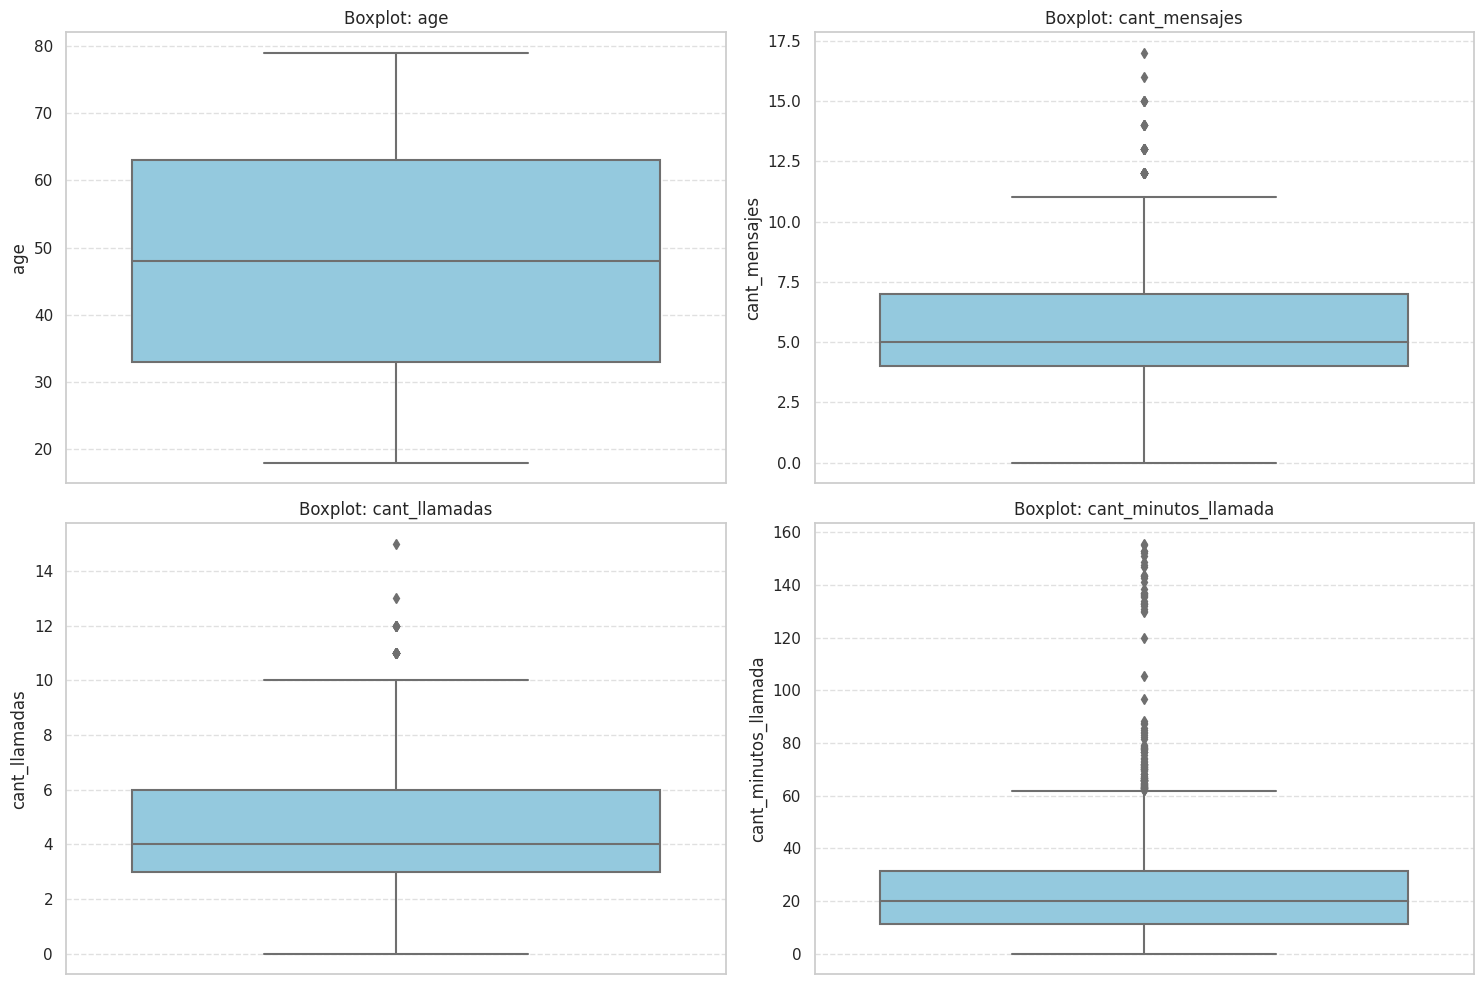

In [36]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
plt.figure(figsize=(15, 10))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=user_profile[col], palette=['skyblue'])
    plt.title(f'Boxplot: {col}')
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

💡Insights: 
- Age: No presenta outliers.
Insight: Los bigotes (whiskers) cubren perfectamente el rango desde los 18 hasta los 80 años. La mediana se sitúa cerca de los 48 años. Esto indica que la base de clientes tiene una distribución demográfica saludable y sin errores de captura de datos (como edades negativas o de 150 años).

- cant_mensajes: Presenta outliers significativos en el límite superior.
Insight: Se observan varios puntos (usuarios) por encima del límite de ~11 mensajes. Hay usuarios extremos que llegan hasta los 17 mensajes. La caja está muy comprimida hacia abajo, lo que confirma que el 75% de la población envía menos de 7 mensajes, pero existe un nicho de "texters" que rompe la norma.


- cant_llamadas:Presenta outliers en el límite superior.
Insight: El límite superior teórico se sitúa en 10 llamadas, pero tenemos usuarios que realizan 11, 13 y hasta 15 llamadas. Estos puntos representan a los clientes con mayor frecuencia de uso, quienes probablemente generan la carga base de señalización en la red.


- cant_minutos_llamada:Presenta una alta densidad de outliers en el límite superior.
Insight: Es el gráfico con la mayor cantidad de valores atípicos. Mientras que el grueso de los usuarios (Q3) consume menos de 35 minutos, existe una "cola" muy poblada de usuarios que llegan hasta los 160 minutos. Estos son los Power Users que disparan el costo operativo y la rentabilidad por excedentes.

In [37]:
# Calcular límites con el método IQR
columnas_limites =  ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("Análisis de Límites Superiores (Método IQR):")
print("-" * 40)

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Solo calculamos límite superior según la instrucción (outliers de un solo lado)
    limite_superior = Q3 + 1.5 * IQR
    valor_maximo = user_profile[col].max()
    
    print(f"Columna: {col}")
    print(f"  Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"  Límite Superior Teórico: {limite_superior:.2f}")
    print(f"  Valor Máximo Real: {valor_maximo:.2f}")
    print("-" * 40)

Análisis de Límites Superiores (Método IQR):
----------------------------------------
Columna: cant_mensajes
  Q3: 7.00 | IQR: 3.00
  Límite Superior Teórico: 11.50
  Valor Máximo Real: 17.00
----------------------------------------
Columna: cant_llamadas
  Q3: 6.00 | IQR: 3.00
  Límite Superior Teórico: 10.50
  Valor Máximo Real: 15.00
----------------------------------------
Columna: cant_minutos_llamada
  Q3: 31.41 | IQR: 20.30
  Límite Superior Teórico: 61.86
  Valor Máximo Real: 155.69
----------------------------------------


In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
Se recomienda mantener todos los outliers para poder analizar de mejor manera cada flujo de datos que pudiera requerirse

1. cant_mensajes
Métricas: Límite Superior Teórico: 11.50 | Máximo Real: 17.00.

Insight: Los usuarios que envían 17 mensajes no representan un error de red ni un comportamiento robótico. Son clientes reales que utilizan el servicio por encima del promedio, pero dentro de parámetros humanos. Borrarlos ocultaría este segmento de ConnectaTel.

2. cant_llamadas
Métricas: Límite Superior Teórico: 10.50 | Máximo Real: 15.00.

Insight: El máximo de 15 llamadas es un valor totalmente plausible para un cliente activo. Al ser datos de uso real, estos outliers son necesarios para dimensionar la capacidad de respuesta de la infraestructura de ConnectaTel.

3. cant_minutos_llamada
Métricas: Límite Superior Teórico: 61.86 | Máximo Real: 155.69.

Insight: Aunque el valor máximo es significativamente mayor al límite teórico, representa a los Power Users. En ConnectaTel, estos usuarios son los más rentables porque generan el mayor volumen de excedentes. Eliminarlos invalidaría cualquier análisis de rentabilidad real.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [39]:
# Crear columna grupo_uso
def categorizar_segmento(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(categorizar_segmento, axis=1)


distribucion_segmentos = user_profile['grupo_uso'].value_counts()
print("Distribución de Segmentos en ConnectaTel:")
print(distribucion_segmentos)

Distribución de Segmentos en ConnectaTel:
Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:
# Crear columna grupo_edad
def categorizar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(categorizar_edad)

print("Distribución demográfica en ConnectaTel:")
print(user_profile['grupo_edad'].value_counts())

Distribución demográfica en ConnectaTel:
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

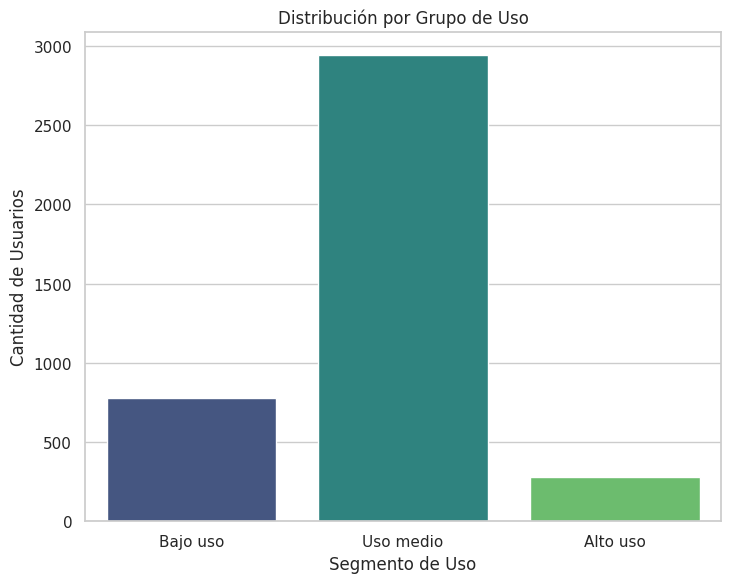

In [43]:
# Visualización de los segmentos por uso
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución por Grupo de Uso')
plt.xlabel('Segmento de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.tight_layout()
plt.show()

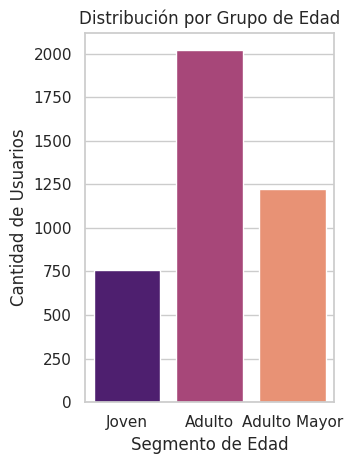

In [44]:
# Visualización de los segmentos por edad
plt.subplot(1, 2, 2)
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución por Grupo de Edad')
plt.xlabel('Segmento de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.tight_layout()
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.


**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?



### Análisis ejecutivo

✍️ Análisis ejecutivo
⚠️ Problemas detectados en los datos

Valores Atípicos de Consumo (Outliers): Se identificó que las variables de consumo (total_minutos_llamada, cant_llamadas y cant_mensajes) presentaban una alta concentración de outliers en el límite superior. En la columna de minutos, los valores extremos representaban aproximadamente el 15.4% de los datos (superando el límite de 61.86 min hasta alcanzar los 155.69 min).

Inconsistencia en Escalas: Originalmente, los datos de uso de los planes mostraban una dispersión masiva que dificultaba la comparación directa de promedios sin antes aplicar la segmentación, debido a que el plan Básico posee un volumen de usuarios mucho mayor que el Premium.

🔍 Segmentos por Edad

Segmento Adulto (30-59 años): Es el grupo predominante en ConnectaTel. Muestran un comportamiento de uso más predecible y constante, siendo la base principal de ingresos fijos.

Segmento Joven (< 30 años): Aunque es un grupo menor en volumen total, presentan picos de intensidad en el uso de mensajería y datos, representando el futuro de la demanda de servicios digitales de la empresa.

📊 Segmentos por Nivel de Uso

Alto Uso: Es el segmento más crítico. A pesar de ser categorizado inicialmente como "outliers", estos usuarios generan la mayor rentabilidad por excedentes, especialmente en el plan Básico donde superan con creces los límites incluidos.

Bajo y Medio Uso: Usuarios que consumen menos de 10 llamadas/mensajes. Representan una carga mínima para la red pero un flujo de efectivo estable por la renta mensual.
➡️ Esto sugiere que...
La estructura actual del plan Básico está diseñada de forma que un porcentaje importante de usuarios (los de Alto Uso) se vean obligados a pagar excedentes mensualmente. El plan Premium actúa como un techo protector: sus usuarios son más valiosos individualmente por su alta cuota, pero los usuarios de "Alto Uso" del plan Básico son los que generan el mayor margen de utilidad variable para ConnectaTel.

💡 Recomendaciones

Migración Estratégica (Upselling): Identificar a los usuarios del plan Básico que se encuentran sistemáticamente en el segmento de "Alto Uso" (más de 62 minutos) y ofrecerles el plan Premium como una medida de "ahorro", asegurando así una renta fija más alta.

Creación del "Plan Connecta-Medio": Implementar un plan intermedio con un límite de 80 minutos y 20 mensajes. Esto capturaría a los usuarios que hoy son outliers en el Básico pero que no dan el salto al Premium, evitando que busquen opciones en la competencia por cobros excesivos de excedentes.

Optimización para Adultos: Dado que el segmento Adulto es el más grande, se recomiendan paquetes de "Llamadas Familiares" ilimitadas para este grupo, incentivando la permanencia y reduciendo la volatilidad de su consumo.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`